In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch

from collections import Counter, defaultdict
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score
from scipy.stats import mannwhitneyu
from matplotlib.patches import Patch

In [2]:
PT_DIR = Path(
    "logs/hidden_states/math/(specific system prompt+no suffix)sharded-at0-ut0_math_meta-llama_Llama-3.1-8B-Instruct"
)
PT_DIR_ADD = Path(
    "logs/hidden_states/math/(add_v2)sharded-at0-ut0_math_meta-llama_Llama-3.1-8B-Instruct"
)
JSONL_PATH = Path(
    "logs/math/sharded-at0-ut0/(specific system prompt+no suffix)sharded-at0-ut0_math_meta-llama_Llama-3.1-8B-Instruct.jsonl"
)
JSONL_PATH_ADD = Path(
    "logs/math/sharded-at0-ut0/(add_v2)sharded-at0-ut0_math_meta-llama_Llama-3.1-8B-Instruct.jsonl"
)

PT_SOURCES    = [PT_DIR, PT_DIR_ADD]
JSONL_SOURCES = [JSONL_PATH, JSONL_PATH_ADD]
LAYERS        = [12, 16, 20, 24, 28]
FOCUS_LAYER_IDX = LAYERS.index(20)   # index used throughout

ALL_TYPES = ["answer_attempt", "clarification", "refusal",
             "hedging", "interrogation", "discussion", "missing"]

# Canonical rt label normalisation
# (data uses "hedge"/"refuse"; normalise to match ALL_TYPES)
RT_NORM = {"hedge": "hedging", "refuse": "refusal"}

TYPE_COLORS = {
    "answer_attempt": "#2196F3",
    "clarification" : "#4CAF50",
    "refusal"       : "#F44336",
    "hedging"       : "#FF9800",
    "interrogation" : "#9C27B0",
    "discussion"    : "#00BCD4",
    "missing"       : "#9E9E9E",
}

In [3]:
def turn_sort_key(label: str):
    if not label.startswith("turn_"):
        return (1, label)
    try:
        return (0, int(label.split("_", 1)[1]))
    except ValueError:
        return (0, label)

def turn_index(label: str) -> int:
    return int(label.split("_", 1)[1])

def cosine(a, b):
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    if na < 1e-9 or nb < 1e-9:
        return np.nan
    return float(np.dot(a, b) / (na * nb))

def styled_ax(ax):
    """Apply dark-theme styling to a matplotlib axis."""
    ax.set_facecolor("#16161e")
    ax.tick_params(colors="#888899")
    for sp in ax.spines.values():
        sp.set_edgecolor("#2a2a3a")

In [4]:
# ── Step 1: Load .pt hidden-state files ──────────────────────────────────────
# Pipeline recap:
#   prefill([sys + Shard0])                     → hs "goal"
#   prefill([sys + Shard0 + Ans0 + Shard1])     → hs "turn_1"
#   prefill([... + Ans1 + Shard2])              → hs "turn_2"  ...
# So hs["turn_N"] = model state BEFORE generating Answer_N.

conv_records = {}
seen, stats = set(), defaultdict(int)

for pt_dir in PT_SOURCES:
    pt_files = sorted(pt_dir.glob("*.pt"))
    print(f"  {pt_dir.name}: {len(pt_files)} files")
    for pt_file in pt_files:
        conv_id = pt_file.stem
        if conv_id in seen:
            stats["duplicate"] += 1; continue
        seen.add(conv_id)

        data        = torch.load(pt_file, map_location="cpu", weights_only=False)
        hs_list     = data.get("hidden_states", [])
        hs_by_label = {e["label"]: e["hidden_states"] for e in hs_list}

        if "goal" not in hs_by_label:
            stats["no_goal"] += 1; continue

        turn_labels = sorted(
            [k for k in hs_by_label if k.startswith("turn_")],
            key=turn_sort_key,
        )
        if len(turn_labels) < 3:
            stats["too_few_turns"] += 1; continue

        conv_records[conv_id] = {
            "goal_hs" : [hs_by_label["goal"][i].numpy() for i in range(len(LAYERS))],
            "turns_hs": {tl: [hs_by_label[tl][i].numpy() for i in range(len(LAYERS))]
                         for tl in turn_labels},
            "max_turn": max(turn_index(tl) for tl in turn_labels),
        }

print(f"\nLoaded: {len(conv_records)} conversations")
for k, v in stats.items():
    if v: print(f"  Skipped ({k}): {v}")

  (specific system prompt+no suffix)sharded-at0-ut0_math_meta-llama_Llama-3.1-8B-Instruct: 103 files
  (add_v2)sharded-at0-ut0_math_meta-llama_Llama-3.1-8B-Instruct: 241 files

Loaded: 320 conversations
  Skipped (too_few_turns): 24


In [5]:
# ── Step 2: Load JSONL → score_map + turn_rt_map ─────────────────────────────
# score_map   : conv_id → 0/1
# turn_rt_map : conv_id → {turn_idx: response_type}
#
# Alignment:
#   user_turn_idx increments on each "user" entry.
#   The "system-verification" log immediately follows the assistant turn,
#   so turn_rt_map[conv_id][N] = type of Answer_N
#   which pairs correctly with hs["turn_N"] (pre-Answer_N state).

score_map   = {}
turn_rt_map = {}

for jsonl_path in JSONL_SOURCES:
    loaded = 0
    with open(jsonl_path) as f:
        for line in f:
            line = line.strip()
            if not line: continue
            rec     = json.loads(line)
            conv_id = rec.get("conv_id")
            if conv_id is None: continue

            score = rec.get("score")
            score_map[conv_id] = int(float(score)) if score is not None else 0

            trace, turn_rt, user_turn_idx = rec.get("trace", []), {}, 0
            for entry in trace:
                role = entry.get("role", "")
                if role == "user":
                    user_turn_idx += 1
                elif role == "log":
                    content = entry.get("content", {})
                    if isinstance(content, dict) and content.get("type") == "system-verification":
                        rt = content.get("response", {}).get("response_type", "missing")
                        rt = RT_NORM.get(rt, rt)   # normalise hedge/refuse
                        turn_rt[user_turn_idx] = rt

            turn_rt_map[conv_id] = turn_rt
            loaded += 1

    print(f"  {jsonl_path.name}: {loaded} records")

n_c = sum(v == 1 for v in score_map.values())
n_i = sum(v == 0 for v in score_map.values())
print(f"\nTotal: {len(score_map)}  (correct={n_c}, incorrect={n_i})")
print("RT distribution:", Counter(rt for d in turn_rt_map.values() for rt in d.values()))

  (specific system prompt+no suffix)sharded-at0-ut0_math_meta-llama_Llama-3.1-8B-Instruct.jsonl: 103 records
  (add_v2)sharded-at0-ut0_math_meta-llama_Llama-3.1-8B-Instruct.jsonl: 241 records

Total: 344  (correct=168, incorrect=176)
RT distribution: Counter({'answer_attempt': 738, 'discussion': 589, 'clarification': 290, 'interrogation': 38, 'hedging': 24, 'refusal': 20, 'missing': 8})


In [6]:
# ── Step 3 (PCA part 1): Build response-type mean vectors ────────────────────
# Mirrors Assistant Axis paper §2.1.2:
#   For each rt, collect all turn hidden states where that type occurred
#   → take mean → one "role vector" per type per layer.
# Note: we use hs["turn_N"] which is pre-Answer_N — correctly captures
# the model state that *leads to* each response strategy.

rt_accum = {li: defaultdict(list) for li in range(len(LAYERS))}

for conv_id, rec in conv_records.items():
    turn_rt  = turn_rt_map.get(conv_id, {})
    for t_label, hs_per_layer in rec["turns_hs"].items():
        t_idx = turn_index(t_label)
        rt    = turn_rt.get(t_idx, "missing")
        for li, hs in enumerate(hs_per_layer):
            rt_accum[li][rt].append(hs)

rt_vectors = {
    li: {rt: np.mean(vecs, axis=0) for rt, vecs in rt_accum[li].items()}
    for li in range(len(LAYERS))
}

print("Sample counts per type (layer 20):")
print({rt: len(v) for rt, v in rt_accum[FOCUS_LAYER_IDX].items()})

Sample counts per type (layer 20):
{'clarification': 280, 'interrogation': 38, 'discussion': 542, 'answer_attempt': 436, 'refusal': 19, 'hedging': 24, 'missing': 8}


In [7]:
# ── Step 3 (PCA part 2): PCA on type-mean vectors → Goal-Commitment Axis ─────
# Mirrors §2.1.3:
#   Subtract cross-type mean → PCA → PC1 = principal axis of rt-space variation

layer_pca = {}

for li, layer in enumerate(LAYERS):
    present = [rt for rt in ALL_TYPES if rt in rt_vectors[li]]
    if len(present) < 2: continue

    mat         = np.stack([rt_vectors[li][rt] for rt in present])
    mat_centred = mat - mat.mean(axis=0, keepdims=True)

    n_comp = min(len(present), 3)
    pca    = PCA(n_components=n_comp)
    coords = pca.fit_transform(mat_centred)

    layer_pca[li] = dict(pca=pca, coords=coords, labels=present,
                          var=pca.explained_variance_ratio_,
                          layer=layer, global_mean=mat.mean(axis=0))

print("Variance explained (PC1 / PC2 / PC3):")
for li, res in sorted(layer_pca.items()):
    var = res["var"]
    v3  = f"{var[2]*100:.1f}%" if len(var) > 2 else "—"
    print(f"  Layer {res['layer']:2d}:  {var[0]*100:.1f}%  {var[1]*100:.1f}%  {v3}")

Variance explained (PC1 / PC2 / PC3):
  Layer 12:  71.4%  13.6%  8.9%
  Layer 16:  71.3%  14.4%  8.4%
  Layer 20:  71.6%  15.7%  6.9%
  Layer 24:  72.4%  14.7%  7.2%
  Layer 28:  71.7%  15.0%  7.5%


Projected 1347 turn points onto PC1 (layer 20)


/tmp/ipykernel_2977452/2763025438.py:124: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


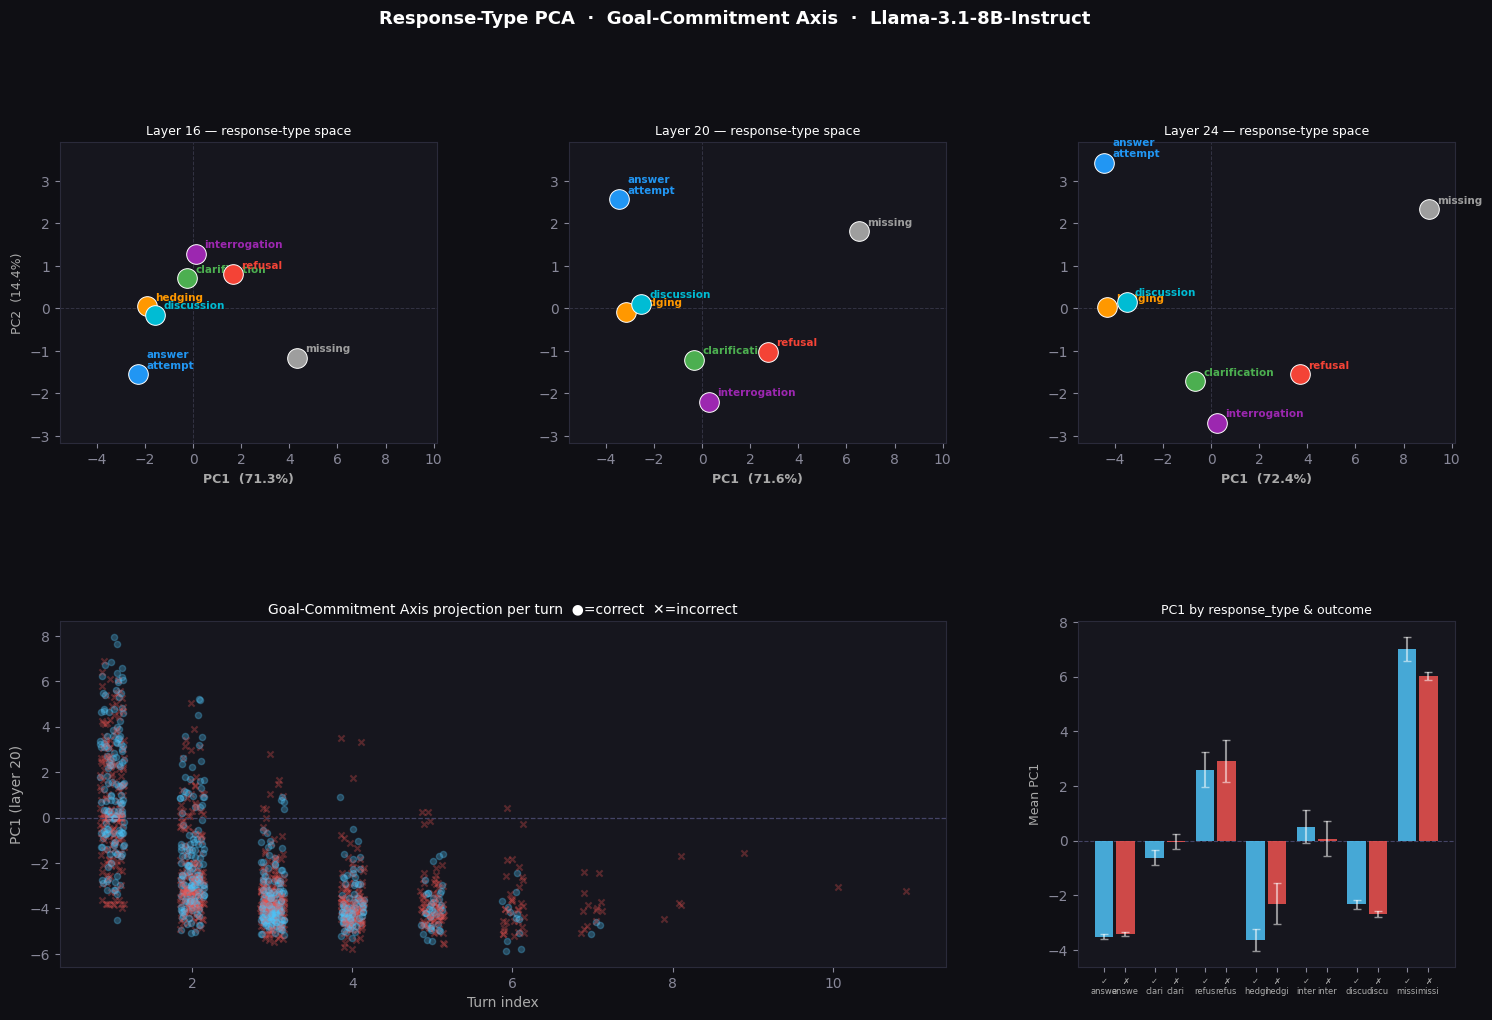

In [8]:
# ── Step 3 (PCA part 3): Plot — type-mean vectors in PC1/PC2 space ───────────
# Row 0: PC1/PC2 scatter for layers 16, 20, 24  (type-mean vectors)
# Row 1 left: turn-level projection onto PC1, by score
# Row 1 right: mean PC1 by rt type and outcome

# Project every turn's hs onto PC1
TARGET_LI  = FOCUS_LAYER_IDX
res_pca    = layer_pca[TARGET_LI]
pca_model  = res_pca["pca"]
g_mean     = res_pca["global_mean"]

scatter = []
for conv_id, rec in conv_records.items():
    score   = score_map.get(conv_id)
    if score is None: continue
    turn_rt = turn_rt_map.get(conv_id, {})
    for t_label, hs_per_layer in rec["turns_hs"].items():
        t_idx = turn_index(t_label)
        hs    = hs_per_layer[TARGET_LI]
        proj  = pca_model.transform((hs - g_mean).reshape(1, -1))[0]
        rt    = turn_rt.get(t_idx, "missing")
        scatter.append(dict(pc1=proj[0],
                            pc2=proj[1] if len(proj) > 1 else 0.0,
                            turn=t_idx, rt=rt, score=score))

print(f"Projected {len(scatter)} turn points onto PC1 (layer {LAYERS[TARGET_LI]})")

fig = plt.figure(figsize=(18, 11))
fig.patch.set_facecolor("#0f0f14")
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# Row 0: PC1/PC2 per layer
selected_layer_values = [16, 20, 24]
selected_lis = [LAYERS.index(l) for l in selected_layer_values]

# Shared axes for direct cross-layer comparison in row 0
pc1_all, pc2_all = [], []
for li in selected_lis:
    res = layer_pca.get(li)
    if res is None:
        continue
    pc1_all.extend(res["coords"][:, 0].tolist())
    if res["coords"].shape[1] > 1:
        pc2_all.extend(res["coords"][:, 1].tolist())

if pc1_all and pc2_all:
    x_span = max(pc1_all) - min(pc1_all)
    y_span = max(pc2_all) - min(pc2_all)
    x_pad = 0.08 * (x_span if x_span > 1e-9 else 1.0)
    y_pad = 0.08 * (y_span if y_span > 1e-9 else 1.0)
    shared_xlim = (min(pc1_all) - x_pad, max(pc1_all) + x_pad)
    shared_ylim = (min(pc2_all) - y_pad, max(pc2_all) + y_pad)
else:
    shared_xlim = None
    shared_ylim = None

for col, li in enumerate(selected_lis):
    ax = fig.add_subplot(gs[0, col])
    styled_ax(ax)
    res = layer_pca.get(li)
    if res is None: continue
    for i, rt in enumerate(res["labels"]):
        c   = res["coords"][i]
        clr = TYPE_COLORS.get(rt, "#aaaaaa")
        ax.scatter(c[0], c[1], color=clr, s=200, zorder=3,
                   edgecolors="white", linewidths=0.7)
        ax.annotate(rt.replace("_", "\n"), (c[0], c[1]),
                    xytext=(6, 4), textcoords="offset points",
                    fontsize=7.5, color=clr, fontweight="bold")
    ax.axhline(0, color="#334", lw=0.7, ls="--")
    ax.axvline(0, color="#334", lw=0.7, ls="--")
    if shared_xlim is not None and shared_ylim is not None:
        ax.set_xlim(*shared_xlim)
        ax.set_ylim(*shared_ylim)
    ax.set_box_aspect(0.8)  # slightly wider panels to emphasize PC1 direction
    ax.set_xlabel(f"PC1  ({res['var'][0]*100:.1f}%)", color="#aaaaaa", fontsize=9, fontweight="bold")
    if col == 0:
        ax.set_ylabel(f"PC2  ({res['var'][1]*100:.1f}%)", color="#aaaaaa", fontsize=9)
    ax.set_title(f"Layer {res['layer']} — response-type space", color="white", fontsize=9, pad=5)

# Row 1 left: turn-level PC1 scatter
ax_b = fig.add_subplot(gs[1, :2])
styled_ax(ax_b)
rng = np.random.default_rng(42)
for pt in scatter:
    jitter = rng.uniform(-0.15, 0.15)
    mk  = "o" if pt["score"] == 1 else "x"
    clr = "#4fc3f7" if pt["score"] == 1 else "#ef5350"
    ax_b.scatter(pt["turn"] + jitter, pt["pc1"],
                 color=clr, alpha=0.3, s=20, marker=mk, zorder=2)
ax_b.axhline(0, color="#446", lw=0.9, ls="--")
ax_b.set_xlabel("Turn index", color="#aaaaaa", fontsize=10)
ax_b.set_ylabel(f"PC1 (layer {LAYERS[TARGET_LI]})", color="#aaaaaa", fontsize=10)
ax_b.set_title("Goal-Commitment Axis projection per turn  ●=correct  ✕=incorrect",
               color="white", fontsize=10, pad=5)

# Row 1 right: mean PC1 by rt × score
ax_c = fig.add_subplot(gs[1, 2])
styled_ax(ax_c)
rt_pc1 = {s: defaultdict(list) for s in [0, 1]}
for pt in scatter:
    rt_pc1[pt["score"]][pt["rt"]].append(pt["pc1"])

xpos = 0; xtick_pos = []; xtick_lbl = []
for rt in ALL_TYPES:
    for score, clr in [(1, "#4fc3f7"), (0, "#ef5350")]:
        vals = rt_pc1[score][rt]
        if not vals: xpos += 0.4; continue
        mu = np.mean(vals); se = np.std(vals) / np.sqrt(len(vals))
        ax_c.bar(xpos, mu, 0.35, color=clr, alpha=0.85,
                 yerr=se, error_kw=dict(ecolor="#ffffff88", capsize=3), zorder=3)
        xtick_pos.append(xpos)
        xtick_lbl.append(f"{'✓' if score==1 else '✗'}\n{rt[:5]}")
        xpos += 0.4
    xpos += 0.15

ax_c.set_xticks(xtick_pos); ax_c.set_xticklabels(xtick_lbl, fontsize=6, color="#aaaaaa")
ax_c.set_ylabel("Mean PC1", color="#aaaaaa", fontsize=9)
ax_c.set_title("PC1 by response_type & outcome", color="white", fontsize=9, pad=5)
ax_c.axhline(0, color="#446", lw=0.8, ls="--")

fig.suptitle("Response-Type PCA  ·  Goal-Commitment Axis  ·  Llama-3.1-8B-Instruct",
             color="white", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig1_pca_response_type_space.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()

Walk records: 320
  correct : 144
  incorrect: 176
  n_turns dist: {3: 118, 4: 86, 5: 70, 6: 30, 7: 12, 8: 3, 11: 1}

── 2D walk (per-step, layer 20) ──
  correct  : n= 144  mean=3.0700  95%CI=[2.8935,3.2395]
  incorrect: n= 176  mean=2.8240  95%CI=[2.6891,2.9593]
  MW-U  correct>incorrect p=0.0398  incorrect>correct p=0.9603

── 3D-weighted walk (per-step, layer 20) ──
  correct  : n= 144  mean=2.1663  95%CI=[2.0346,2.3004]
  incorrect: n= 176  mean=1.9059  95%CI=[1.8039,2.0134]
  MW-U  correct>incorrect p=0.0036  incorrect>correct p=0.9964


/tmp/ipykernel_2977452/3946582539.py:254: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


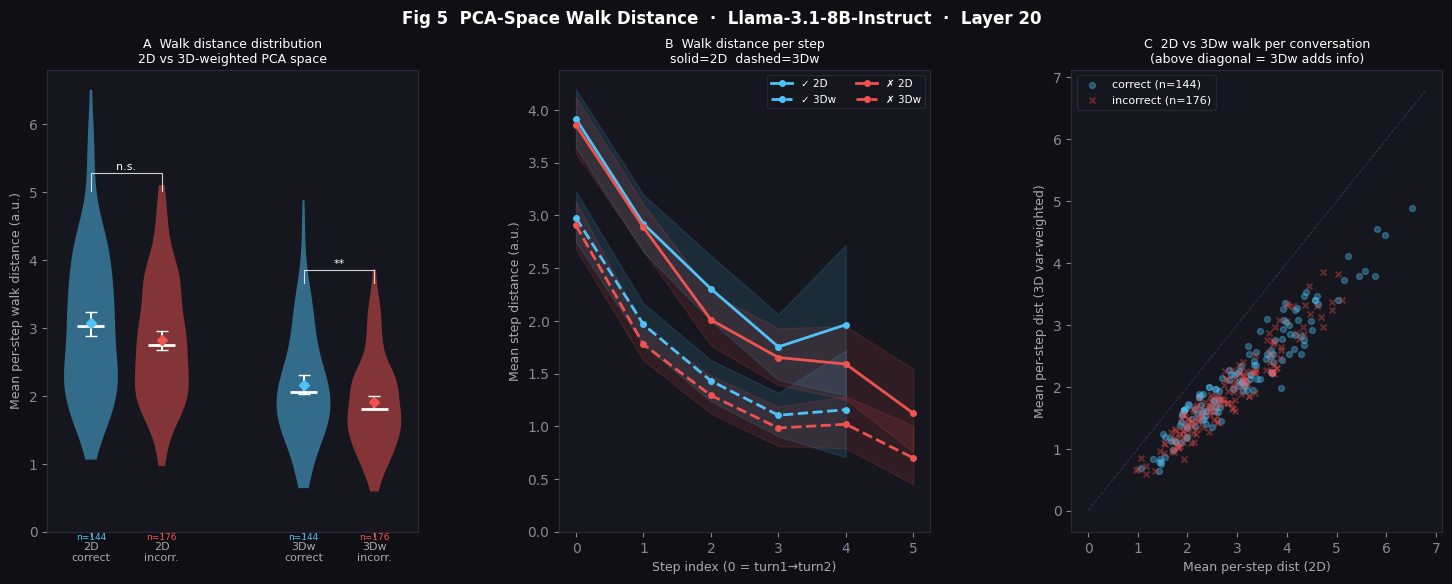

Saved fig5_pca_walk_distance.png


In [9]:
# ── Step 3 (PCA part 4): PCA-Space Walk Distance ────────────────────────────
# Metric: for each conversation, project every turn's hidden state into the
#         RT-PCA space (same pca_model used in Part 3), then sum the Euclidean
#         distances between consecutive turns in that low-D space.
#
# Two variants:
#   • 2D  : use PC1, PC2
#   • 3D-w: use PC1, PC2, PC3 weighted by their variance-explained ratio
#             coord_weighted = coord * sqrt(var_ratio)
#
# Normalise by (n_turns - 1) to get mean per-step displacement,
# making conversations of different lengths comparable.
#
# Then compare correct vs. incorrect with Mann-Whitney U + bootstrap CI.
# Also plot per-turn mean displacement as a trajectory (like Fig 4).

import warnings

TARGET_LI  = FOCUS_LAYER_IDX           # layer 20
res_pca    = layer_pca[TARGET_LI]
pca_model  = res_pca["pca"]
g_mean     = res_pca["global_mean"]
var_ratio  = res_pca["var"]            # [var_pc1, var_pc2, var_pc3]

N_BOOT  = 2000
MIN_TURNS = 3          # need at least 3 turns to compute 2+ steps
RNG = np.random.default_rng(0)

# ── 1. Project every turn per conversation ───────────────────────────────────
walk_records = []   # list of dicts, one per conversation

for conv_id, rec in conv_records.items():
    score = score_map.get(conv_id)
    if score is None:
        continue

    turn_labels = sorted(
        [k for k in rec["turns_hs"] if k.startswith("turn_")],
        key=lambda l: int(l.split("_")[1]),
    )
    if len(turn_labels) < MIN_TURNS:
        continue

    # Stack hidden states → project
    hs_mat = np.stack([rec["turns_hs"][tl][TARGET_LI] for tl in turn_labels])
    projs  = pca_model.transform(hs_mat - g_mean)   # shape (T, n_comp)

    n_comp = projs.shape[1]

    # 2D coords
    coords_2d = projs[:, :2]                         # (T, 2)

    # 3D variance-weighted coords  (sqrt so that squared-distance = var-weighted)
    if n_comp >= 3:
        w = np.sqrt(var_ratio[:3])                   # (3,)
        coords_3dw = projs[:, :3] * w                # (T, 3)
    else:
        coords_3dw = None

    # Step distances
    diffs_2d  = np.diff(coords_2d,  axis=0)          # (T-1, 2)
    dist_2d   = np.linalg.norm(diffs_2d, axis=1)     # (T-1,)

    if coords_3dw is not None:
        diffs_3dw = np.diff(coords_3dw, axis=0)
        dist_3dw  = np.linalg.norm(diffs_3dw, axis=1)
    else:
        dist_3dw = None

    turn_idxs = [int(tl.split("_")[1]) for tl in turn_labels]

    walk_records.append(dict(
        conv_id    = conv_id,
        score      = score,
        n_turns    = len(turn_labels),
        max_turn   = rec["max_turn"],
        total_2d   = float(dist_2d.sum()),
        mean_2d    = float(dist_2d.mean()),          # per-step mean
        total_3dw  = float(dist_3dw.sum())  if dist_3dw is not None else np.nan,
        mean_3dw   = float(dist_3dw.mean()) if dist_3dw is not None else np.nan,
        step_dist_2d  = dist_2d.tolist(),
        step_dist_3dw = dist_3dw.tolist() if dist_3dw is not None else [],
        step_turns    = turn_idxs[1:],               # turn index of destination
    ))

print(f"Walk records: {len(walk_records)}")
print(f"  correct : {sum(r['score']==1 for r in walk_records)}")
print(f"  incorrect: {sum(r['score']==0 for r in walk_records)}")
print(f"  n_turns dist: {dict(sorted(dict(zip(*np.unique([r['n_turns'] for r in walk_records], return_counts=True))).items()))}")

# ── 2. Bootstrap CI helper ───────────────────────────────────────────────────
def boot_ci(arr, n=N_BOOT, ci=95):
    arr = np.asarray(arr)
    if len(arr) == 0:
        return np.nan, np.nan, np.nan
    means = [np.mean(RNG.choice(arr, len(arr), replace=True)) for _ in range(n)]
    lo, hi = np.percentile(means, [(100-ci)/2, 100-(100-ci)/2])
    return float(np.mean(arr)), lo, hi

# ── 3. Summary stats ─────────────────────────────────────────────────────────
for metric, col in [("2D walk", "mean_2d"), ("3D-weighted walk", "mean_3dw")]:
    c_vals = [r[col] for r in walk_records if r["score"]==1 and not np.isnan(r[col])]
    i_vals = [r[col] for r in walk_records if r["score"]==0 and not np.isnan(r[col])]
    mu_c, lo_c, hi_c = boot_ci(c_vals)
    mu_i, lo_i, hi_i = boot_ci(i_vals)
    if len(c_vals)>=5 and len(i_vals)>=5:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            _, p_c_gt_i = mannwhitneyu(c_vals, i_vals, alternative="greater")
            _, p_i_gt_c = mannwhitneyu(i_vals, c_vals, alternative="greater")
    else:
        p_c_gt_i = p_i_gt_c = np.nan
    print(f"\n── {metric} (per-step, layer {LAYERS[TARGET_LI]}) ──")
    print(f"  correct  : n={len(c_vals):4d}  mean={mu_c:.4f}  95%CI=[{lo_c:.4f},{hi_c:.4f}]")
    print(f"  incorrect: n={len(i_vals):4d}  mean={mu_i:.4f}  95%CI=[{lo_i:.4f},{hi_i:.4f}]")
    print(f"  MW-U  correct>incorrect p={p_c_gt_i:.4f}  incorrect>correct p={p_i_gt_c:.4f}")

# ── 4. Figure: 3-panel ───────────────────────────────────────────────────────
# Panel A: violin of mean per-step distance (2D vs 3Dw) × score
# Panel B: mean distance per turn-step trajectory, correct vs incorrect
# Panel C: scatter – conversation-level (2D walk, 3Dw walk), coloured by score

fig = plt.figure(figsize=(18, 6))
fig.patch.set_facecolor("#0f0f14")
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.38)

CLR_C = "#4fc3f7"   # correct
CLR_I = "#ef5350"   # incorrect

# ── Panel A: violin ──────────────────────────────────────────────────────────
ax = fig.add_subplot(gs[0]); styled_ax(ax)

group_data = {}
for metric, col, label in [
    ("2D",   "mean_2d",  "2D"),
    ("3D-w", "mean_3dw", "3D\nvar-weighted"),
]:
    for score, clr, slabel in [(1, CLR_C, "correct"), (0, CLR_I, "incorrect")]:
        vals = [r[col] for r in walk_records
                if r["score"]==score and not np.isnan(r[col])]
        group_data[(metric, score)] = vals

positions  = [0.0, 0.5, 1.5, 2.0]
grp_keys   = [("2D",1), ("2D",0), ("3D-w",1), ("3D-w",0)]
grp_colors = [CLR_C, CLR_I, CLR_C, CLR_I]
grp_labels = ["2D\ncorrect","2D\nincorr.","3Dw\ncorrect","3Dw\nincorr."]

vp = ax.violinplot(
    [group_data[k] for k in grp_keys],
    positions=positions,
    widths=0.38, showmedians=True, showextrema=False,
)
for body, clr in zip(vp["bodies"], grp_colors):
    body.set_facecolor(clr); body.set_alpha(0.50)
vp["cmedians"].set_color("white"); vp["cmedians"].set_linewidth(2)

for pos, key, clr in zip(positions, grp_keys, grp_colors):
    vals = group_data[key]
    mu, lo, hi = boot_ci(vals)
    ax.errorbar(pos, mu, yerr=[[mu-lo],[hi-mu]],
                fmt="D", color=clr, ms=5, lw=1.5, zorder=5,
                capsize=4, ecolor="white")
    ax.text(pos, -0.01, f"n={len(vals)}", ha="center",
            fontsize=6.5, color=clr, va="top")

# significance brackets
for (k1, k2, xs) in [
    (("2D",1),   ("2D",0),   (0.0, 0.5)),
    (("3D-w",1), ("3D-w",0), (1.5, 2.0)),
]:
    v1, v2 = group_data[k1], group_data[k2]
    if len(v1)>=5 and len(v2)>=5:
        _, p = mannwhitneyu(v1, v2, alternative="two-sided")
        star = "***" if p<0.001 else "**" if p<0.01 else "*" if p<0.05 else "n.s."
        top  = max(np.percentile(v1+v2,97), np.mean(v1+v2))*1.05
        ax.plot([xs[0], xs[0], xs[1], xs[1]],
                [top*0.95, top, top, top*0.95], lw=0.8, color="white", alpha=0.8)
        ax.text(sum(xs)/2, top*1.01, star, ha="center", fontsize=8, color="white")

ax.set_xticks(positions); ax.set_xticklabels(grp_labels, fontsize=8, color="#aaaaaa")
ax.set_ylabel("Mean per-step walk distance (a.u.)", color="#aaaaaa", fontsize=9)
ax.set_title("A  Walk distance distribution\n2D vs 3D-weighted PCA space",
             color="white", fontsize=9, pad=5)
ax.set_ylim(bottom=0)

# ── Panel B: per-step trajectory ─────────────────────────────────────────────
ax = fig.add_subplot(gs[1]); styled_ax(ax)

# Collect step distances keyed by (relative_step, score)
# Use relative step index (0-based from conversation start) for alignment
MAX_STEPS = 8
step_by_score_2d  = {s: defaultdict(list) for s in [0, 1]}
step_by_score_3dw = {s: defaultdict(list) for s in [0, 1]}

for r in walk_records:
    for si, d2 in enumerate(r["step_dist_2d"]):
        if si < MAX_STEPS:
            step_by_score_2d[r["score"]][si].append(d2)
    for si, d3 in enumerate(r["step_dist_3dw"]):
        if si < MAX_STEPS:
            step_by_score_3dw[r["score"]][si].append(d3)

for score, clr in [(1, CLR_C), (0, CLR_I)]:
    for metric_dict, ls, label_suffix in [
        (step_by_score_2d,  "-",  "2D"),
        (step_by_score_3dw, "--", "3Dw"),
    ]:
        d = metric_dict[score]
        xs  = sorted(k for k in d if len(d[k]) >= 5)
        if not xs: continue
        ys    = [np.mean(d[x]) for x in xs]
        boots = [boot_ci(d[x]) for x in xs]
        los   = [b[1] for b in boots]
        his   = [b[2] for b in boots]
        ax.plot(xs, ys, color=clr, ls=ls, lw=2, marker="o", ms=4,
                label=f"{'✓' if score==1 else '✗'} {label_suffix}")
        ax.fill_between(xs, los, his, color=clr, alpha=0.12)

ax.set_xlabel("Step index (0 = turn1→turn2)", color="#aaaaaa", fontsize=9)
ax.set_ylabel("Mean step distance (a.u.)", color="#aaaaaa", fontsize=9)
ax.set_title("B  Walk distance per step\nsolid=2D  dashed=3Dw",
             color="white", fontsize=9, pad=5)
ax.legend(facecolor="#16161e", edgecolor="#2a2a3a", labelcolor="white",
          fontsize=7.5, ncol=2)
ax.set_ylim(bottom=0)

# ── Panel C: conversation-level scatter (2D vs 3Dw) ──────────────────────────
ax = fig.add_subplot(gs[2]); styled_ax(ax)

for score, clr, mk in [(1, CLR_C, "o"), (0, CLR_I, "x")]:
    subset = [r for r in walk_records
              if r["score"]==score
              and not np.isnan(r["mean_2d"])
              and not np.isnan(r["mean_3dw"])]
    x = [r["mean_2d"]  for r in subset]
    y = [r["mean_3dw"] for r in subset]
    ax.scatter(x, y, color=clr, alpha=0.35, s=18, marker=mk,
               label=f"{'correct' if score==1 else 'incorrect'} (n={len(subset)})")

# diagonal reference
lim = max(ax.get_xlim()[1], ax.get_ylim()[1])
ax.plot([0, lim], [0, lim], color="#334", lw=0.7, ls="--")

ax.set_xlabel("Mean per-step dist (2D)", color="#aaaaaa", fontsize=9)
ax.set_ylabel("Mean per-step dist (3D var-weighted)", color="#aaaaaa", fontsize=9)
ax.set_title("C  2D vs 3Dw walk per conversation\n(above diagonal = 3Dw adds info)",
             color="white", fontsize=9, pad=5)
ax.legend(facecolor="#16161e", edgecolor="#2a2a3a", labelcolor="white", fontsize=8)

fig.suptitle(
    f"Fig 5  PCA-Space Walk Distance  ·  Llama-3.1-8B-Instruct  ·  Layer {LAYERS[TARGET_LI]}",
    color="white", fontsize=12, fontweight="bold",
)
plt.tight_layout()
plt.savefig("fig5_pca_walk_distance.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("Saved fig5_pca_walk_distance.png")


In [10]:
# ── Step 4: Build curvature records ──────────────────────────────────────────
# For each conv, at focus layer:
#   delta_t = hs[t] - hs[t-1]
#   curvature_t = cos(delta_t, delta_{t-1})   ← defined from turn index 3+
#
# Each record: (conv_id, turn_idx, rt, score, curvature, is_transition)
# rt alignment: turn_rt[N] = type of Answer_N, paired with hs["turn_N"]
# which is the pre-Answer_N state → causal direction correct.

records = []

for conv_id, rec in conv_records.items():
    score   = score_map.get(conv_id)
    if score is None: continue
    turn_rt  = turn_rt_map.get(conv_id, {})
    turns_hs = rec["turns_hs"]

    turn_labels = sorted(
        [k for k in turns_hs if k.startswith("turn_")],
        key=lambda l: int(l.split("_")[1])
    )
    if len(turn_labels) < 3: continue

    idxs   = [int(l.split("_")[1]) for l in turn_labels]
    hs_seq = [turns_hs[l][FOCUS_LAYER_IDX] for l in turn_labels]
    deltas = [hs_seq[i] - hs_seq[i-1] for i in range(1, len(hs_seq))]

    for i in range(1, len(deltas)):
        t_idx   = idxs[i + 1]
        rt      = turn_rt.get(t_idx, "missing")
        rt_prev = turn_rt.get(idxs[i], "missing")
        records.append({
            "conv_id"       : conv_id,
            "turn"          : t_idx,
            "score"         : score,
            "rt"            : rt,
            "rt_prev"       : rt_prev,
            "is_transition" : rt != rt_prev,
            "curvature"     : cosine(deltas[i], deltas[i-1]),
            "max_turn"      : rec["max_turn"],
        })

print(f"Built {len(records)} (conv, turn) curvature records")
print("RT distribution in records:", Counter(r["rt"] for r in records))

Built 707 (conv, turn) curvature records
RT distribution in records: Counter({'answer_attempt': 354, 'discussion': 244, 'clarification': 93, 'hedging': 10, 'interrogation': 6})


In [11]:
# ── Step 5: Build bigram transition stats ────────────────────────────────────
# bigram_stats[(rt_t, rt_{t+1})] = {correct, total}
# Used for transition matrix and path-sequence analysis.

bigram_stats = defaultdict(lambda: {"correct": 0, "total": 0})

for conv_id, rec in conv_records.items():
    score   = score_map.get(conv_id)
    if score is None: continue
    turn_rt = turn_rt_map.get(conv_id, {})
    turn_labels = sorted(
        [k for k in rec["turns_hs"] if k.startswith("turn_")],
        key=lambda l: int(l.split("_")[1])
    )
    if len(turn_labels) < 2: continue
    idxs   = [int(l.split("_")[1]) for l in turn_labels]
    rt_seq = [turn_rt.get(i, "missing") for i in idxs]
    for a, b in zip(rt_seq, rt_seq[1:]):
        bigram_stats[(a, b)]["total"]   += 1
        bigram_stats[(a, b)]["correct"] += score

print("Top 10 bigrams (rt[t] → rt[t+1]):")
for (a, b), s in sorted(bigram_stats.items(), key=lambda x: -x[1]["total"])[:10]:
    pct = 100 * s["correct"] / s["total"] if s["total"] else 0
    print(f"  {a:20s} → {b:20s}  n={s['total']:4d}  correct={pct:.0f}%")

Top 10 bigrams (rt[t] → rt[t+1]):
  discussion           → discussion            n= 237  correct=37%
  answer_attempt       → answer_attempt        n= 211  correct=29%
  discussion           → answer_attempt        n= 137  correct=33%
  clarification        → clarification         n=  90  correct=67%
  clarification        → discussion            n=  84  correct=43%
  clarification        → answer_attempt        n=  53  correct=47%
  discussion           → clarification         n=  51  correct=51%
  answer_attempt       → discussion            n=  42  correct=26%
  interrogation        → clarification         n=  15  correct=53%
  clarification        → interrogation         n=  12  correct=33%


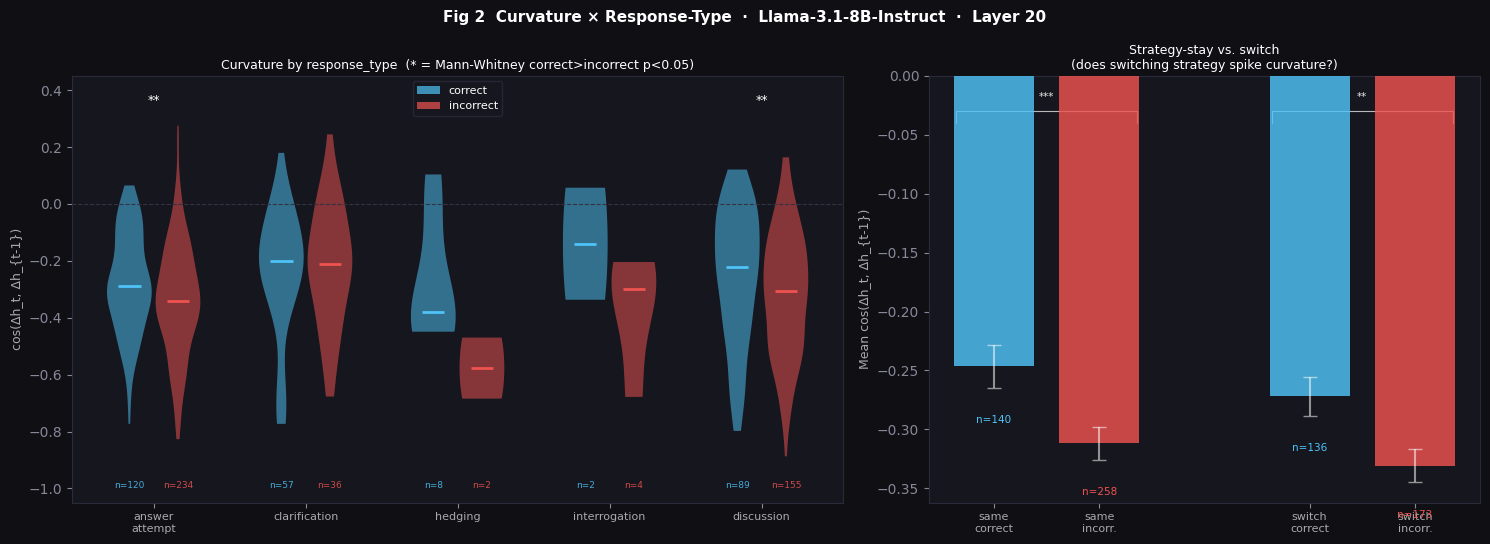

In [12]:
# ── Fig 2: Curvature × Response-Type ─────────────────────────────────────────
# Left:  violin — curvature distribution per rt, correct vs incorrect
#        + Mann-Whitney U significance stars
# Right: bar — curvature at strategy-stay vs. strategy-switch

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5),
                         gridspec_kw={"width_ratios": [1.4, 1]})
fig.patch.set_facecolor("#0f0f14")

# ── Left: violin ──────────────────────────────────────────────────────────────
ax = axes[0]; styled_ax(ax)
rt_curve = {rt: {"correct": [], "incorrect": []} for rt in ALL_TYPES}
for r in records:
    if np.isnan(r["curvature"]) or r["rt"] == "missing": continue
    rt_curve[r["rt"]]["correct" if r["score"]==1 else "incorrect"].append(r["curvature"])

present  = [rt for rt in ALL_TYPES if rt_curve[rt]["correct"] or rt_curve[rt]["incorrect"]]
positions = np.arange(len(present))
w = 0.32

for offset, key, clr in [(-w/2, "correct", "#4fc3f7"), (w/2, "incorrect", "#ef5350")]:
    vals = [rt_curve[rt][key] for rt in present]
    vp = ax.violinplot(vals, positions=positions+offset,
                       widths=w*0.92, showmedians=True, showextrema=False)
    for body in vp["bodies"]:
        body.set_facecolor(clr); body.set_alpha(0.52)
    vp["cmedians"].set_color(clr); vp["cmedians"].set_linewidth(2)
    for xi, vs in zip(positions+offset, vals):
        ax.text(xi, -1.0, f"n={len(vs)}", ha="center", fontsize=6.5, color=clr, alpha=0.85)

for xi, rt in zip(positions, present):
    vc = rt_curve[rt]["correct"]; vi = rt_curve[rt]["incorrect"]
    if len(vc) >= 5 and len(vi) >= 5:
        _, p = mannwhitneyu(vc, vi, alternative="greater")
        star = "***" if p<0.001 else "**" if p<0.01 else "*" if p<0.05 else ""
        if star: ax.text(xi, 0.35, star, ha="center", fontsize=9, color="white")

ax.set_xticks(positions)
ax.set_xticklabels([rt.replace("_","\n") for rt in present], fontsize=8, color="#aaaaaa")
ax.set_ylim(-1.05, 0.45)
ax.set_ylabel("cos(Δh_t, Δh_{t-1})", color="#aaaaaa", fontsize=9)
ax.set_title("Curvature by response_type  (* = Mann-Whitney correct>incorrect p<0.05)",
             color="white", fontsize=9, pad=5)
ax.axhline(0, color="#334", lw=0.8, ls="--")
ax.legend(handles=[Patch(facecolor="#4fc3f7", alpha=0.7, label="correct"),
                   Patch(facecolor="#ef5350", alpha=0.7, label="incorrect")],
          facecolor="#16161e", edgecolor="#2a2a3a", labelcolor="white", fontsize=8)

# ── Right: stay vs. switch ────────────────────────────────────────────────────
ax = axes[1]; styled_ax(ax)
groups = {("same",1):[], ("same",0):[], ("change",1):[], ("change",0):[]}
for r in records:
    if np.isnan(r["curvature"]): continue
    key = ("change" if r["is_transition"] else "same", r["score"])
    groups[key].append(r["curvature"])

bar_defs = [
    ("same\ncorrect",   ("same",  1), "#4fc3f7", 0.00),
    ("same\nincorrect", ("same",  0), "#ef5350", 0.50),
    ("switch\ncorrect", ("change",1), "#4fc3f7", 1.50),
    ("switch\nincorr.", ("change",0), "#ef5350", 2.00),
]
for lbl, key, clr, xpos in bar_defs:
    vals = groups[key]
    if not vals: continue
    mu = np.mean(vals); se = np.std(vals)/np.sqrt(len(vals))
    ax.bar(xpos, mu, 0.38, color=clr, alpha=0.82,
           yerr=se, error_kw=dict(ecolor="#ffffff88", capsize=5), zorder=3)
    ax.text(xpos, mu-se-0.03, f"n={len(vals)}", ha="center", fontsize=7.5, color=clr)

# Significance brackets
for k1, k2, xs in [(("same",1),("same",0),(0.0,0.5)),
                    (("change",1),("change",0),(1.5,2.0))]:
    v1, v2 = groups[k1], groups[k2]
    if len(v1)>=5 and len(v2)>=5:
        _, p = mannwhitneyu(v1, v2, alternative="greater")
        star = "***" if p<0.001 else "**" if p<0.01 else "*" if p<0.05 else "n.s."
        mid  = sum(xs)/2
        ax.plot([xs[0]-0.18, xs[0]-0.18, xs[1]+0.18, xs[1]+0.18],
                [-0.04, -0.03, -0.03, -0.04], lw=0.8, color="white", alpha=0.7)
        ax.text(mid, -0.02, star, ha="center", fontsize=7.5, color="white", alpha=0.9)

ax.set_xticks([0.0, 0.5, 1.5, 2.0])
ax.set_xticklabels(["same\ncorrect","same\nincorr.","switch\ncorrect","switch\nincorr."],
                   fontsize=8, color="#aaaaaa")
ax.set_ylabel("Mean cos(Δh_t, Δh_{t-1})", color="#aaaaaa", fontsize=9)
ax.set_title("Strategy-stay vs. switch\n(does switching strategy spike curvature?)",
             color="white", fontsize=9, pad=5)
ax.axhline(0, color="#334", lw=0.8, ls="--")

fig.suptitle("Fig 2  Curvature × Response-Type  ·  Llama-3.1-8B-Instruct  ·  Layer 20",
             color="white", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig("fig2_curvature_x_rt.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()

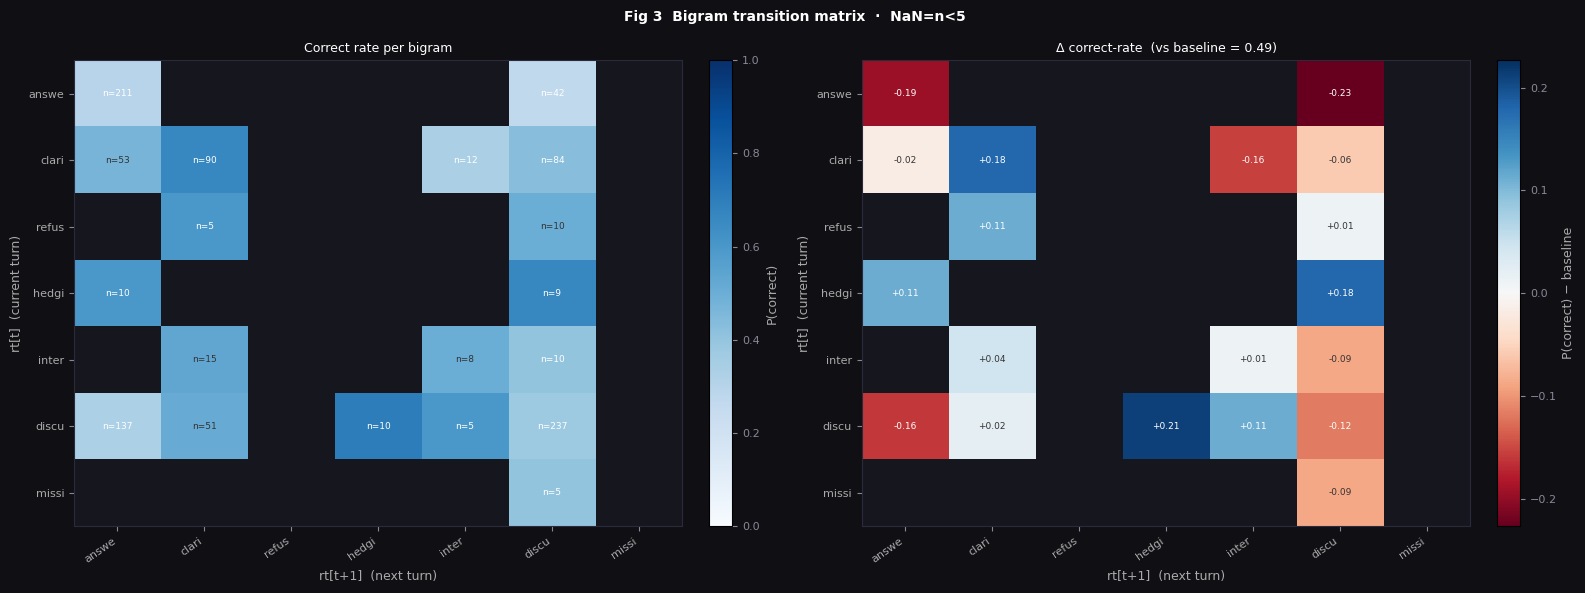

In [13]:
# ── Fig 3: Bigram transition matrix ──────────────────────────────────────────
# Left:  absolute correct rate per (rt[t], rt[t+1]) bigram
# Right: deviation from dataset baseline  Δ = P(correct) − baseline

MIN_N    = 5
baseline = sum(score_map.values()) / len(score_map)
rt2i     = {rt: i for i, rt in enumerate(ALL_TYPES)}

mat   = np.full((len(ALL_TYPES), len(ALL_TYPES)), np.nan)
count = np.zeros((len(ALL_TYPES), len(ALL_TYPES)), dtype=int)
for (a, b), s in bigram_stats.items():
    if a not in rt2i or b not in rt2i: continue
    i, j = rt2i[a], rt2i[b]
    count[i, j] = s["total"]
    if s["total"] >= MIN_N:
        mat[i, j] = s["correct"] / s["total"]

diff_mat = np.where(np.isnan(mat), np.nan, mat - baseline)
short    = [rt[:5] for rt in ALL_TYPES]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor("#0f0f14")

specs = [
    (mat,      "Blues", 0, 1,
     "Correct rate per bigram",
     "P(correct)",
     lambda v, n: f"n={n}"),
    (diff_mat, "RdBu",  None, None,
     f"Δ correct-rate  (vs baseline = {baseline:.2f})",
     "P(correct) − baseline",
     lambda v, n: f"{v:+.2f}"),
]
for ax, (data, cmap, vmin, vmax, title, cblbl, fmt) in zip(axes, specs):
    styled_ax(ax)
    vext = np.nanmax(np.abs(data)) if vmin is None else None
    kw   = dict(cmap=cmap, aspect="auto",
                vmin=(vmin if vmin is not None else -vext),
                vmax=(vmax if vmax is not None else  vext))
    im = ax.imshow(data, **kw)
    cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.ax.tick_params(colors="#888899", labelsize=8)
    cb.set_label(cblbl, color="#aaaaaa", fontsize=9)

    for i in range(len(ALL_TYPES)):
        for j in range(len(ALL_TYPES)):
            v = data[i, j]; n = count[i, j]
            if not np.isnan(v):
                bright = abs(v - (0.5 if vmin==0 else 0)) > (vext or 0.15)*0.4
                ax.text(j, i, fmt(v, n), ha="center", va="center",
                        fontsize=6.5, color="white" if bright else "#333")

    ax.set_xticks(range(len(ALL_TYPES))); ax.set_yticks(range(len(ALL_TYPES)))
    ax.set_xticklabels(short, rotation=35, ha="right", fontsize=8, color="#aaaaaa")
    ax.set_yticklabels(short, fontsize=8, color="#aaaaaa")
    ax.set_xlabel("rt[t+1]  (next turn)", color="#aaaaaa", fontsize=9)
    ax.set_ylabel("rt[t]  (current turn)", color="#aaaaaa", fontsize=9)
    ax.set_title(title, color="white", fontsize=9, pad=6)

fig.suptitle(f"Fig 3  Bigram transition matrix  ·  NaN=n<{MIN_N}",
             color="white", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.savefig("fig3_bigram_matrix.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()

Stage distribution (total_turns=4):
Counter({'late': 38, 'never': 31, 'mid': 11, 'early': 6})


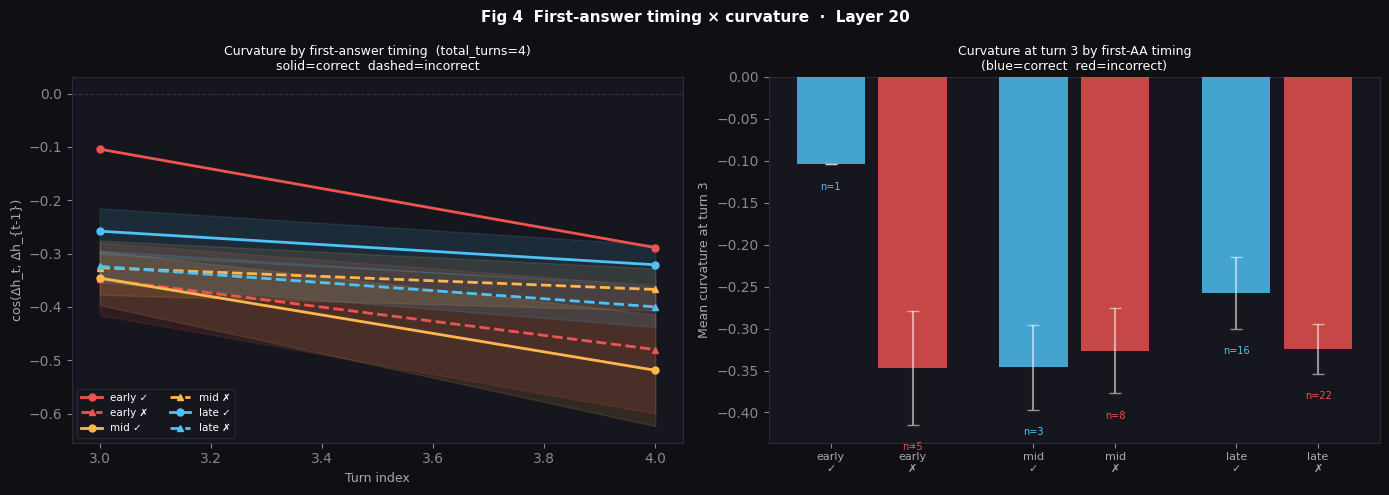

In [14]:
# ── Fig 4: First-answer-attempt timing × curvature ───────────────────────────
# Classifies each conv by when the first answer_attempt occurs (early/mid/late)
# then plots curvature trajectory by timing stage × score.
# Directly bridges Fig 3 (answer timing → correct rate) to hidden-state level.

def aa_stage(conv_id):
    turn_rt = turn_rt_map.get(conv_id, {})
    turn_labels = sorted(
        [k for k in conv_records[conv_id]["turns_hs"] if k.startswith("turn_")],
        key=lambda l: int(l.split("_")[1])
    )
    idxs    = [int(l.split("_")[1]) for l in turn_labels]
    aa_idxs = [i for i in idxs if turn_rt.get(i) == "answer_attempt"]
    if not aa_idxs: return "never"
    rel = min(aa_idxs) / conv_records[conv_id]["max_turn"]
    return "early" if rel <= 0.25 else "mid" if rel <= 0.60 else "late"

STAGES       = ["early", "mid", "late"]
STAGE_COLORS = {"early": "#ef5350", "mid": "#FFB74D", "late": "#4fc3f7"}
TARGET_TOTAL = 4   # cleanest signal from temporal curvature plots

stage_curves = defaultdict(lambda: defaultdict(list))
for conv_id, rec in conv_records.items():
    score = score_map.get(conv_id)
    if score is None or rec["max_turn"] != TARGET_TOTAL: continue
    stage = aa_stage(conv_id)
    if stage == "never": continue

    turn_rt  = turn_rt_map.get(conv_id, {})
    turn_labels = sorted(
        [k for k in rec["turns_hs"] if k.startswith("turn_")],
        key=lambda l: int(l.split("_")[1])
    )
    idxs   = [int(l.split("_")[1]) for l in turn_labels]
    hs_seq = [rec["turns_hs"][l][FOCUS_LAYER_IDX] for l in turn_labels]
    deltas = [hs_seq[i] - hs_seq[i-1] for i in range(1, len(hs_seq))]

    for i in range(1, len(deltas)):
        t_idx = idxs[i+1]
        c = cosine(deltas[i], deltas[i-1])
        if not np.isnan(c):
            stage_curves[(stage, score)][t_idx].append(c)

print("Stage distribution (total_turns=4):")
print(Counter(aa_stage(c) for c in conv_records
              if score_map.get(c) is not None
              and conv_records[c]["max_turn"] == TARGET_TOTAL))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("#0f0f14")

# Left: curvature trajectory by stage × score
ax = axes[0]; styled_ax(ax)
for stage in STAGES:
    clr = STAGE_COLORS[stage]
    for score, ls, mk in [(1, "-", "o"), (0, "--", "^")]:
        d = stage_curves[(stage, score)]
        xs  = sorted(d.keys())
        if not xs: continue
        ys  = [np.mean(d[t]) for t in xs]
        ses = [np.std(d[t])/np.sqrt(len(d[t])) for t in xs]
        ax.plot(xs, ys, color=clr, ls=ls, lw=2, marker=mk, ms=5,
                label=f"{stage} {'✓' if score==1 else '✗'}")
        ax.fill_between(xs, [y-s for y,s in zip(ys,ses)],
                            [y+s for y,s in zip(ys,ses)],
                        color=clr, alpha=0.12)
ax.axhline(0, color="#334", lw=0.8, ls="--")
ax.set_xlabel("Turn index", color="#aaaaaa", fontsize=9)
ax.set_ylabel("cos(Δh_t, Δh_{t-1})", color="#aaaaaa", fontsize=9)
ax.set_title(f"Curvature by first-answer timing  (total_turns={TARGET_TOTAL})\n"
             "solid=correct  dashed=incorrect",
             color="white", fontsize=9, pad=5)
ax.legend(facecolor="#16161e", edgecolor="#2a2a3a", labelcolor="white",
          fontsize=7.5, ncol=2)

# Right: mean curvature at turn 3 per stage × score
ax = axes[1]; styled_ax(ax)
T3 = min(s for d in stage_curves.values() for s in d)  # earliest available turn
xpos = 0; xticks = []; xlabels = []
for stage in STAGES:
    for score, clr in [(1,"#4fc3f7"), (0,"#ef5350")]:
        vals = stage_curves[(stage, score)].get(T3, [])
        if not vals: xpos += 0.42; continue
        mu = np.mean(vals); se = np.std(vals)/np.sqrt(len(vals))
        ax.bar(xpos, mu, 0.35, color=clr, alpha=0.82,
               yerr=se, error_kw=dict(ecolor="#ffffff88", capsize=4), zorder=3)
        ax.text(xpos, mu-se-0.03, f"n={len(vals)}", ha="center", fontsize=7, color=clr)
        xticks.append(xpos); xlabels.append(f"{stage}\n{'✓' if score==1 else '✗'}")
        xpos += 0.42
    xpos += 0.2

ax.set_xticks(xticks); ax.set_xticklabels(xlabels, fontsize=8, color="#aaaaaa")
ax.set_ylabel(f"Mean curvature at turn {T3}", color="#aaaaaa", fontsize=9)
ax.set_title(f"Curvature at turn {T3} by first-AA timing\n"
             "(blue=correct  red=incorrect)",
             color="white", fontsize=9, pad=5)
ax.axhline(0, color="#334", lw=0.8, ls="--")

fig.suptitle("Fig 4  First-answer timing × curvature  ·  Layer 20",
             color="white", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig("fig4_aa_timing_curvature.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()

In [15]:
# ── Summary table: mean curvature by rt × outcome (Mann-Whitney U) ────────────
print(f"{'rt':22s}  {'nc':>5}  {'mean_c':>8}  {'ni':>5}  {'mean_i':>8}  {'Δ(c-i)':>8}  {'p(U)':>8}")
for rt in ALL_TYPES:
    vc = [r["curvature"] for r in records if r["rt"]==rt and r["score"]==1 and not np.isnan(r["curvature"])]
    vi = [r["curvature"] for r in records if r["rt"]==rt and r["score"]==0 and not np.isnan(r["curvature"])]
    mc   = np.mean(vc) if vc else float("nan")
    mi   = np.mean(vi) if vi else float("nan")
    diff = mc - mi if not (np.isnan(mc) or np.isnan(mi)) else float("nan")
    if len(vc)>=5 and len(vi)>=5:
        _, p = mannwhitneyu(vc, vi, alternative="greater")
        pstr = f"{p:.4f}" + (" *" if p<0.05 else "")
    else:
        pstr = "n/a"
    print(f"  {rt:20s}  {len(vc):5d}  {mc:8.4f}  {len(vi):5d}  {mi:8.4f}  {diff:+8.4f}  {pstr:>9}")

rt                         nc    mean_c     ni    mean_i    Δ(c-i)      p(U)
  answer_attempt          120   -0.2765    234   -0.3360   +0.0595   0.0024 *
  clarification            57   -0.2403     36   -0.2191   -0.0212     0.5549
  refusal                   0       nan      0       nan      +nan        n/a
  hedging                   8   -0.2710      2   -0.5769   +0.3059        n/a
  interrogation             2   -0.1398      4   -0.3699   +0.2301        n/a
  discussion               89   -0.2492    155   -0.3134   +0.0642   0.0084 *
  missing                   0       nan      0       nan      +nan        n/a
